In [1]:
print("'Aarif Rahmaan Jalaluddin Faqiih")
print("PS1IF-12-REG06")
print("103112430182")
print("https://colab.research.google.com/drive/1Uvr-UDssI-PA1fwnORBz0kzqrm1jzV4c?usp=sharing")
print("https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/UTS")

'Aarif Rahmaan Jalaluddin Faqiih
PS1IF-12-REG06
103112430182
https://colab.research.google.com/drive/1Uvr-UDssI-PA1fwnORBz0kzqrm1jzV4c?usp=sharing
https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/UTS


# Soal 1

### [1] Import Library dan Definisi Fungsi Visualisasi

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

# Fungsi untuk menampilkan graf
def show_graph(G, pos=None, title='', labels={}):
    if pos is None:
        pos = nx.spring_layout(G)

    nx.draw(
        G,
        pos,
        with_labels=True,
        labels=labels,
        node_color='red',
        node_size=2000,
        font_color="white",
        font_weight="bold",
        width=5
    )

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_color='blue',
        font_weight="bold",
        font_size=12
    )

    plt.margins(0.2)
    plt.title(title)
    plt.show()

### [2] Inisialisasi Graf dan Definisi Data

Elemen pada Graf:
Daftar Node: ['S', 'A', 'B', 'C', 'D', 'E', 'G']
Daftar Edge: [('S', 'A'), ('S', 'B'), ('S', 'C'), ('A', 'D'), ('B', 'D'), ('B', 'E'), ('C', 'E'), ('D', 'G'), ('E', 'G')]


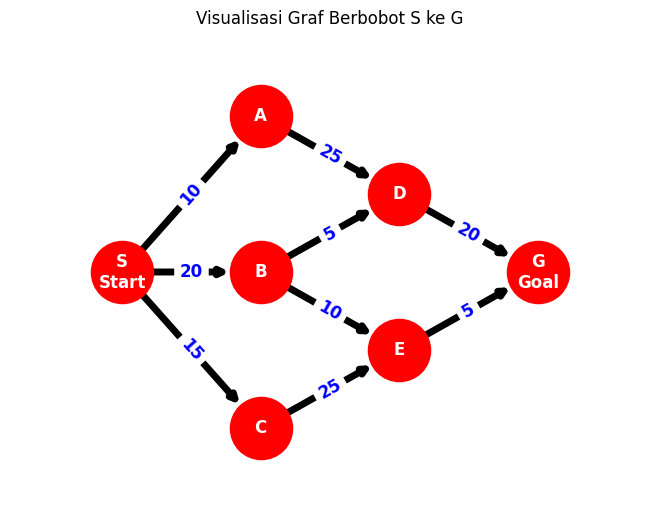

In [3]:
# Posisi node
pos = {
    'S': (0, 2),
    'A': (2, 3), 'B': (2, 2), 'C': (2, 1),
    'D': (4, 2.5), 'E': (4, 1.5),
    'G': (6, 2)
}

# Inisialisasi graf berarah
G = nx.DiGraph()

# Tambahkan edge dan weight
edges = [
    ('S', 'A', 10), ('S', 'B', 20), ('S', 'C', 15),
    ('A', 'D', 25), ('B', 'D', 5), ('B', 'E', 10),
    ('C', 'E', 25), ('D', 'G', 20), ('E', 'G', 5)
]
G.add_weighted_edges_from(edges)

# Evaluasi elemen pada graf
print("Elemen pada Graf:")
print("Daftar Node:", list(G.nodes()))
print("Daftar Edge:", list(G.edges()))

labels = {node: node for node in G.nodes()}
labels['S'] = 'S\nStart'
labels['G'] = 'G\nGoal'

show_graph(G, pos=pos, labels=labels, title="Visualisasi Graf Berbobot S ke G")

### [3] Implementasi Depth First Search (DFS)

In [4]:
# Menjalankan DFS untuk mencari jalur dari S ke G
# Menggunakan nx.dfs_edges untuk melihat urutan kunjungan
print("--- PROSES DEPTH FIRST SEARCH ---")
dfs_path = list(nx.all_simple_paths(G, source='S', target='G'))[0] # Mengambil jalur pertama yang ditemukan DFS

# Menghitung total cost untuk jalur DFS
dfs_cost = sum(G[dfs_path[i]][dfs_path[i+1]]['weight'] for i in range(len(dfs_path)-1))

print("Urutan node yang dikunjungi (DFS):", dfs_path)
print("Total cost jalur DFS:", dfs_cost)

--- PROSES DEPTH FIRST SEARCH ---
Urutan node yang dikunjungi (DFS): ['S', 'A', 'D', 'G']
Total cost jalur DFS: 55


### [4] Implementasi Uniform Cost Search (UCS)

In [5]:
# Fungsi heuristik konstan nol (untuk UCS)
def heuristable(a, b):
    return 0

# UCS dari S ke G menggunakan A* dengan heuristik nol
path_node = nx.astar_path(G, 'S', 'G', heuristic=heuristable, weight='weight')
path_length = nx.astar_path_length(G, 'S', 'G', heuristic=heuristable, weight='weight')

print("--- HASIL UNIFORM COST SEARCH (Jalur Terpendek) ---")
print("Node yang dikunjungi dari S ke G:", path_node)
print("Besar weight terkecil (Total Cost):", path_length)

--- HASIL UNIFORM COST SEARCH (Jalur Terpendek) ---
Node yang dikunjungi dari S ke G: ['S', 'B', 'E', 'G']
Besar weight terkecil (Total Cost): 35


### [5] Analisis Manual Proses UCS (Langkah demi Langkah)

In [6]:
def manual_ucs(graph, start, goal):
    queue = [(0, start, [start])]
    visited = set()

    print(f"Mencari jalur dari {start} ke {goal}...\n")

    while queue:
        cost, current, path = heapq.heappop(queue)

        if current == goal:
            return path, cost

        if current not in visited:
            visited.add(current)
            for neighbor in graph.neighbors(current):
                weight = graph[current][neighbor]['weight']
                heapq.heappush(queue, (cost + weight, neighbor, path + [neighbor]))
    return None, float('inf')

final_path, final_cost = manual_ucs(G, 'S', 'G')
print("=== KESIMPULAN ===")
print(f"Jalur Terbaik (UCS) : {' -> '.join(final_path)}")
print(f"Total Minimum Cost  : {final_cost}")

Mencari jalur dari S ke G...

=== KESIMPULAN ===
Jalur Terbaik (UCS) : S -> B -> E -> G
Total Minimum Cost  : 35


# Penjelasan Soal 1

Kode ini bertujuan untuk mencari jalur terpendek dari node S ke node G di dalam graf berarah berbobot.


1. import libraru
import networkx as nx,
import matplotlib.pyplot as plt, dan
import heapq

- networkx = library untuk membuat dan memproses graf.
- matplotlib.pyplot = untuk menggambar graf.
- heapq = digunakan di fungsi manual_ucs untuk antrean prioritas agar selalu mengambil biaya terkecil terlebih dulu.


2. Fungsi show_graph
Tujuannya untuk menampilkan graf
- nx.draw() = menggambar node dan edge.
- nx.draw_networkx_edge_labels() = menulis bobot setiap edge.
plt.show() = print gambar.


3. Membuat graf berarah (DiGraph) dan menambah edge

```
G = nx.DiGraph()
edges = [
    ('S', 'A', 10), ('S', 'B', 20), ('S', 'C', 15),
    ('A', 'D', 25), ('B', 'D', 5), ('B', 'E', 10),
    ('C', 'E', 25), ('D', 'G', 20), ('E', 'G', 5)
]
G.add_weighted_edges_from(edges)
```

- Setiap edge ditulis sebagai (dari, ke, bobot).
- Graf ini berarah (arah panah dari node pertama ke node kedua).


4. Depth First Search (DFS) dari S ke G

```
dfs_path = list(nx.all_simple_paths(G, source='S', target='G'))[0]
dfs_cost = sum(G[dfs_path[i]][dfs_path[i+1]]['weight'] for i in range(len(dfs_path)-1))
```

- all_simple_paths menghasilkan semua kemungkinan jalur dari S ke G.
- [0] mengambil jalur pertama yang ditemukan.
- Kemudian dihitung total bobot dari jalur itu.


5. Uniform Cost Search (UCS) menggunakan astar_path dengan heuristik 0
- astar_path mengembalikan urutan node dari S ke G yang total bobotnya paling kecil.
- astar_path_length mengembalikan total biayanya.


6. Fungsi manual_ucs

```
def manual_ucs(graph, start, goal):
    queue = [(0, start, [start])]
    visited = set()
    while queue:
        cost, current, path = heapq.heappop(queue)
        if current == goal:
            return path, cost
        if current not in visited:
            visited.add(current)
            for neighbor in graph.neighbors(current):
                weight = graph[current][neighbor]['weight']
                heapq.heappush(queue, (cost + weight, neighbor, path + [neighbor]))
    return None, float('inf')
```

- queue berisi tupel (total_biaya, node_saat_ini, jalur_sampai_node_ini).
- heapq.heappop selalu mengeluarkan item dengan biaya terkecil.
- Jika node yang diambil adalah tujuan (goal), langsung berhenti dan kembalikan jalurnya.
- Jika node belum dikunjungi (visited), tandai sudah dikunjungi, lalu masukkan semua tetangganya ke antrian dengan biaya yang ditambah bobot edge.
- Karena menggunakan heapq, algoritma ini otomatis memprioritaskan jalur dengan biaya paling kecil.

# Soal 2

### [1] Import Library dan Definisi Data Graf

In [7]:
import random
import math
import networkx as nx

# Definisi data nodes dan edges
nodes = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]
edges_data = [
    ("A", "B", 6), ("A", "D", 6), ("A", "F", 3),
    ("B", "C", 3), ("B", "D", 2),
    ("C", "D", 1), ("C", "E", 5),
    ("D", "E", 8), ("D", "G", 5),
    ("E", "I", 5), ("E", "J", 5),
    ("F", "G", 1), ("F", "H", 7),
    ("G", "I", 3),
    ("H", "I", 2),
    ("I", "J", 3)
]

# Heuristic costs
heuristic_costs = {
    "A": 10, "B": 8, "C": 5, "D": 7, "E": 3,
    "F": 6, "G": 5, "H": 3, "I": 1, "J": 0
}

# Inisialisasi graf
G = nx.Graph()
for u, v, w in edges_data:
    G.add_edge(u, v, weight=w)

### [2] Fungsi Pendukung Kalkulasi Cost dan Validasi Rute

In [8]:
# Fungsi untuk menghitung total actual cost dari sebuah jalur
def calculate_actual_cost(path, graph):
    total = 0
    for i in range(len(path) - 1):
        if graph.has_edge(path[i], path[i+1]):
            total += graph[path[i]][path[i+1]]['weight']
        else:
            return float('inf') # Jalur tidak valid
    return total

# Fungsi untuk menghasilkan tetangga
# Kita akan mencoba mencari jalur alternatif dengan mencari path baru
def get_random_neighbor_path(graph, start, goal):
    # Menggunakan fungsi untuk mencari semua jalur sebagai pool solusi
    all_paths = list(nx.all_simple_paths(graph, source=start, target=goal))
    return random.choice(all_paths)

### [3] Implementasi Algoritma Simulated Annealing

In [9]:
def simulated_annealing_path(graph, start, goal, initial_temp, cooling_rate, stopping_temp):
    # Inisialisasi solusi awal (jalur acak dari A ke J)
    all_paths = list(nx.all_simple_paths(graph, source=start, target=goal))
    current_solution = random.choice(all_paths)
    current_cost = calculate_actual_cost(current_solution, graph)

    best_solution = current_solution[:]
    best_cost = current_cost

    temp = initial_temp
    iteration = 1

    print(f"=== MULAI SIMULATED ANNEALING (A -> J) ===")
    print(f"Jalur awal : {current_solution}")
    print(f"Cost awal  : {current_cost}\n")

    while temp > stopping_temp:
        # Cari solusi tetangga (jalur alternatif)
        new_solution = random.choice(all_paths)
        new_cost = calculate_actual_cost(new_solution, graph)

        # Hitung selisih cost (Delta E)
        delta = new_cost - current_cost

        # Logika penerimaan solusi
        if delta < 0:
            # Solusi baru lebih baik
            current_solution = new_solution[:]
            current_cost = new_cost
            accept = True
        else:
            # Solusi baru lebih buruk, cek probabilitas
            probability = math.exp(-delta / temp)
            if random.random() < probability:
                current_solution = new_solution[:]
                current_cost = new_cost
                accept = True
            else:
                accept = False

        # Update best solution jika ditemukan yang lebih murah
        if current_cost < best_cost:
            best_solution = current_solution[:]
            best_cost = current_cost
            print(f"Iterasi {iteration}: Update BEST! Cost = {best_cost} | Jalur = {best_solution}")

        # Cooling down
        temp *= cooling_rate
        iteration += 1

    return best_solution, best_cost

### [4] Eksekusi dan Hasil Akhir

In [10]:
# Parameter Algoritma
initial_temp = 1000
cooling_rate = 0.95
stopping_temp = 0.01

# Eksekusi pencarian rute dari A ke J
best_path, total_actual_cost = simulated_annealing_path(
    G, 'A', 'J', initial_temp, cooling_rate, stopping_temp
)

print("\n" + "="*30)
print("       HASIL AKHIR")
print("="*30)
print(f"Jalur Solusi : {' -> '.join(best_path)}")
print(f"Actual Cost  : {total_actual_cost}")
print("="*30)

=== MULAI SIMULATED ANNEALING (A -> J) ===
Jalur awal : ['A', 'F', 'G', 'I', 'E', 'J']
Cost awal  : 17

Iterasi 5: Update BEST! Cost = 15 | Jalur = ['A', 'F', 'H', 'I', 'J']
Iterasi 67: Update BEST! Cost = 10 | Jalur = ['A', 'F', 'G', 'I', 'J']

       HASIL AKHIR
Jalur Solusi : A -> F -> G -> I -> J
Actual Cost  : 10


# Penjelasan Soal 2

1. Import library
- random digunakan untuk memilih jalur secara acak.
- math digunakan untuk menghitung exp() di probabilitas.


2. Data graf
- Nodes = ["A", "B", ..., "J"].
- edges_data = daftar hubungan antar node plus bobot (cost).


3. Fungsi calculate_actual_cost(path, graph)
- Input sebuah jalur (list node) dan graf.
- Output total bobot dari semua edge yang dilalui.
- Jika ada edge yang tidak ada di graf, fungsi ngembaliin float('inf') (tak terhingga), artinya jalur tidak valid.


4. Fungsi get_random_neighbor_path

```
def get_random_neighbor_path(graph, start, goal):
    all_paths = list(nx.all_simple_paths(graph, source=start, target=goal))
    return random.choice(all_paths)
```

- Ambil semua jalur dari start ke goal yang tidak mengunjungi node lebih dari sekali (simple path).
- Pilih satu secara acak sebagai tetangga.


5. Fungsi utama simulated_annealing_path

Parameter:
- `graph`, `start`, `goal`
- `initial_temp` = suhu awal (1000)
- `cooling_rate` = laju pendinginan (0.95)
- `stopping_temp` = suhu berhenti (0.01)

a. Siapkan semua jalur yang mungkin
```
all_paths = list(nx.all_simple_paths(graph, source=start, target=goal))
```

b. Solusi awal

Pilih jalur acak dari `all_paths`, hitung cost-nya.

c. Simpan solusi terbaik

Salin jalur awal sebagai `best_solution` dan `best_cost`.

d. Loop selama suhu > stopping_temp

- Pilih jalur baru (acak dari `all_paths`), hitung cost-nya.
- Hitung `delta = new_cost - current_cost`.
- Jika delta < 0 (jalur baru lebih murah), terima langsung.
- Jika delta >= 0 (jalur baru lebih mahal), hitung probabilitas = `exp(-delta / temp)`.

Terima jalur baru jika angka acak `random.random()` lebih kecil dari probabilitas itu.

- Jika `current_cost` lebih kecil dari `best_cost`, perbarui solusi terbaik dan cetak info.

- Turunkan suhu: `temp *= cooling_rate`.

- Tambah `iteration`.

e. Kembalikan solusi terbaik dan cost-nya.


6. Parameter dan eksekusi

```
initial_temp = 1000
cooling_rate = 0.95
stopping_temp = 0.01

best_path, total_actual_cost = simulated_annealing_path(G, 'A', 'J', initial_temp, cooling_rate, stopping_temp)
```

- Jalankan SA dari A ke J.
- Print hasil akhir untuk jalur dan total biaya.